<a href="https://colab.research.google.com/github/Ololade18/CMP7239/blob/main/BODMAS_Ololade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/drive')
# Then access it at:
# /drive/MyDrive/bodmas.zip

Mounted at /drive


In [2]:
import os
for root, dirs, files_list in os.walk('/drive/MyDrive'):
    for file in files_list:
        if 'archive' in file.lower():
            print(os.path.join(root, file))

/drive/MyDrive/Colab Notebooks/archive (1).zip


In [3]:
import zipfile
import os

# Unzip
zip_path = '/drive/MyDrive/Colab Notebooks/archive (1).zip'
extract_path = '/content/bodmas/'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:", z.namelist())
    z.extractall(extract_path)

print("✓ Extracted successfully")
print(os.listdir(extract_path))

Files in zip: ['bodmas-timestamps.parquet', 'bodmas.parquet']
✓ Extracted successfully
['bodmas.parquet', 'bodmas-timestamps.parquet']


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load only first 5000 rows
df = pd.read_parquet('/content/bodmas/bodmas.parquet')
df_sample = df.head(5000)

print(f"Sample shape: {df_sample.shape}")
print(f"Label distribution:\n{df_sample['Label'].value_counts()}")
print(f"Missing values: {df_sample.isnull().sum().sum()}")

Sample shape: (5000, 2385)
Label distribution:
Label
0.0    5000
Name: count, dtype: int64
Missing values: 5000


In [5]:
# Build feature names
feature_names = []
for i in range(256): feature_names.append(f"histogram_{i}")
for i in range(256): feature_names.append(f"byteentropy_{i}")
feature_names += ["strings_numstrings","strings_avlength","strings_printables"]
for i in range(96): feature_names.append(f"strings_printabledist_{i}")
feature_names += ["strings_entropy","strings_paths","strings_urls","strings_registry","strings_MZ"]
for f in ["size","vsize","has_debug","exports","imports","has_relocations","has_resources","has_signature","has_tls","symbols"]:
    feature_names.append(f"general_{f}")
feature_names.append("header_timestamp")
for i in range(10): feature_names.append(f"header_machine_{i}")
for i in range(10): feature_names.append(f"header_characteristics_{i}")
for i in range(10): feature_names.append(f"header_subsystem_{i}")
for i in range(10): feature_names.append(f"header_dll_characteristics_{i}")
for i in range(10): feature_names.append(f"header_magic_{i}")
for f in ["major_image_version","minor_image_version","major_linker_version","minor_linker_version",
          "major_os_version","minor_os_version","major_subsystem_version","minor_subsystem_version",
          "sizeof_code","sizeof_headers","sizeof_heap_commit"]:
    feature_names.append(f"header_{f}")
for f in ["num_sections","zero_size","empty_name","rx_sections","w_sections"]:
    feature_names.append(f"section_{f}")
for i in range(50): feature_names.append(f"section_sizes_{i}")
for i in range(50): feature_names.append(f"section_entropy_{i}")
for i in range(50): feature_names.append(f"section_vsize_{i}")
for i in range(50): feature_names.append(f"section_entry_name_{i}")
for i in range(50): feature_names.append(f"section_characteristics_{i}")
for i in range(256): feature_names.append(f"imports_libs_{i}")
for i in range(1024): feature_names.append(f"imports_funcs_{i}")
for i in range(128): feature_names.append(f"exports_{i}")
dirs = ["EXPORT_TABLE","IMPORT_TABLE","RESOURCE_TABLE","EXCEPTION_TABLE","CERTIFICATE_TABLE",
        "BASE_RELOCATION_TABLE","DEBUG","ARCHITECTURE","GLOBAL_PTR","TLS_TABLE",
        "LOAD_CONFIG_TABLE","BOUND_IMPORT","IAT","DELAY_IMPORT_DESCRIPTOR","CLR_RUNTIME_HEADER"]
for d in dirs:
    feature_names.append(f"datadirs_{d}_size")
    feature_names.append(f"datadirs_{d}_vaddress")

print(f"Total feature names: {len(feature_names)}")

# Apply rename to dataframe
f_cols = [c for c in df.columns if c.startswith('F') and c[1:].isdigit()]
rename_map = {col: feature_names[int(col[1:]) - 1] for col in f_cols}
df = df.rename(columns=rename_map)

print("✓ Columns renamed!")
print(df.columns[:10].tolist())

Total feature names: 2381
✓ Columns renamed!
['histogram_0', 'histogram_1', 'histogram_2', 'histogram_3', 'histogram_4', 'histogram_5', 'histogram_6', 'histogram_7', 'histogram_8', 'histogram_9']


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import time

# Balanced sample - 10000 benign + 10000 malware
df_benign = df[df['Label'] == 0].head(10000)
df_malware = df[df['Label'] == 1].head(10000)
df_sample = pd.concat([df_benign, df_malware]).reset_index(drop=True)

print(f"Sample shape: {df_sample.shape}")
print(f"Label distribution:\n{df_sample['Label'].value_counts()}")

# Separate features and labels
non_feature_cols = ['Label', 'sha256', 'family', 'category']
X = df_sample.drop(columns=non_feature_cols).values
y = df_sample['Label'].values
feature_col_names = [c for c in df_sample.columns if c not in non_feature_cols]

# Handle nulls
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Select top 50 features
selector = SelectKBest(f_classif, k=50)
X_50 = selector.fit_transform(X, y)
selected_indices = selector.get_support(indices=True)
selected_features = [feature_col_names[i] for i in selected_indices]

print(f"\nTop 50 features selected ✓")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_50)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(df_sample.head())
print("✓ Ready to retrain all 6 models!")

Sample shape: (20000, 2385)
Label distribution:
Label
0.0    10000
1.0    10000
Name: count, dtype: int64

Top 50 features selected ✓
Training set: (16000, 50)
Test set:     (4000, 50)
   histogram_0  histogram_1  histogram_2  histogram_3  histogram_4  \
0     0.056742     0.008017     0.007762     0.005466     0.007762   
1     0.007062     0.004500     0.004498     0.004318     0.004410   
2     0.020975     0.004699     0.004002     0.004419     0.004214   
3     0.006482     0.003821     0.003788     0.003866     0.003734   
4     0.022135     0.003972     0.003834     0.003869     0.003759   

   histogram_5  histogram_6  histogram_7  histogram_8  histogram_9  ...  \
0     0.004446     0.005430     0.003061     0.009475     0.006305  ...   
1     0.004330     0.004265     0.004068     0.004391     0.004306  ...   
2     0.003865     0.003973     0.004297     0.003921     0.004145  ...   
3     0.003784     0.003884     0.003937     0.003805     0.003809  ...   
4     0.003765     

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 628 635 636 638 648 649 650 652 659 663 666 667 669 670 672 673 674
 675 676 849 857 858 859 862 867 868 873 880 883 890 891 894 896 898 899
 900 904 905 908 909 910 912 913 917 918 919 920 922 923 924 925 926 931
 932 933 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


It takes 20,000 PE files from the BODMAS dataset, picks the 50 most useful features, normalises the numbers, and splits everything into a training set and a test set ready for the six models to be trained on.

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

# Recreate X and y from your renamed dataframe
non_feature_cols = ['Label', 'sha256', 'family', 'category']
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X = df[feature_cols]
y = df['Label']

# Refit selector
selector = SelectKBest(f_classif, k=50)
selector.fit(X, y)

# Now print the top 50 features with their F-scores
feature_scores = pd.DataFrame({
    'Rank': range(1, 51),
    'Feature': X.columns[selector.get_support()],
    'F-Score': selector.scores_[selector.get_support()]
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

feature_scores['Rank'] = range(1, 51)
print(feature_scores.to_string(index=False))

 Rank                        Feature      F-Score
    1   header_dll_characteristics_1 63063.124047
    2       header_characteristics_0 41245.832239
    3          general_has_signature 35564.667363
    4       header_characteristics_5 32572.103433
    5              general_has_debug 31883.702895
    6       header_characteristics_4 28520.004023
    7          general_has_resources 26540.976200
    8       header_characteristics_3 20874.291474
    9              section_entropy_5 18871.619818
   10        general_has_relocations 18821.897001
   11             header_subsystem_8 18705.383918
   12 header_major_subsystem_version 18097.376857
   13     section_characteristics_37 16677.461465
   14                   histogram_53 16176.499229
   15             header_subsystem_7 15705.259360
   16   header_dll_characteristics_8 15396.416950
   17    header_major_linker_version 14655.665044
   18              imports_funcs_564 14387.351016
   19               imports_funcs_67 13815.855697


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 635 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676
 849 859 862 867 883 891 894 896 898 899 900 904 905 908 909 910 912 913
 917 919 920 922 923 924 925 926 931 932 934 936 937] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


This cell scores all 2,381 features by how well each one separates malware from benign samples. The F-statistic essentially asks does this feature look different between the two classes? The higher the score, the more useful the feature. header_dll_characteristics_1 came out top with an F-score of 63,063, meaning it has the strongest statistical separation between the two classes of any feature in the dataset. The table shows all 50 selected features ranked in that order.

In [8]:
import pandas as pd

feature_scores = pd.DataFrame({
    'Feature': X.columns[selector.get_support()],
    'F-Score': selector.scores_[selector.get_support()]
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print(feature_scores.to_string())

                           Feature       F-Score
0     header_dll_characteristics_1  63063.124047
1         header_characteristics_0  41245.832239
2            general_has_signature  35564.667363
3         header_characteristics_5  32572.103433
4                general_has_debug  31883.702895
5         header_characteristics_4  28520.004023
6            general_has_resources  26540.976200
7         header_characteristics_3  20874.291474
8                section_entropy_5  18871.619818
9          general_has_relocations  18821.897001
10              header_subsystem_8  18705.383918
11  header_major_subsystem_version  18097.376857
12      section_characteristics_37  16677.461465
13                    histogram_53  16176.499229
14              header_subsystem_7  15705.259360
15    header_dll_characteristics_8  15396.416950
16     header_major_linker_version  14655.665044
17               imports_funcs_564  14387.351016
18                imports_funcs_67  13815.855697
19                im

It just builds a two-column table showing the 50 selected features and their F-scores, sorted highest to lowest, and prints it.

MACHINE LEARNING ALGORITHMS
1. Decision Tree
2. Random Forest
3. XG Boost
4. K Nearest Neighbours


Training Decision Tree...
✓ Trained in 0.96s

Accuracy: 0.9413 (94.12%)

Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.94      0.94      2000
     Malware       0.94      0.95      0.94      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weighted avg       0.94      0.94      0.94      4000



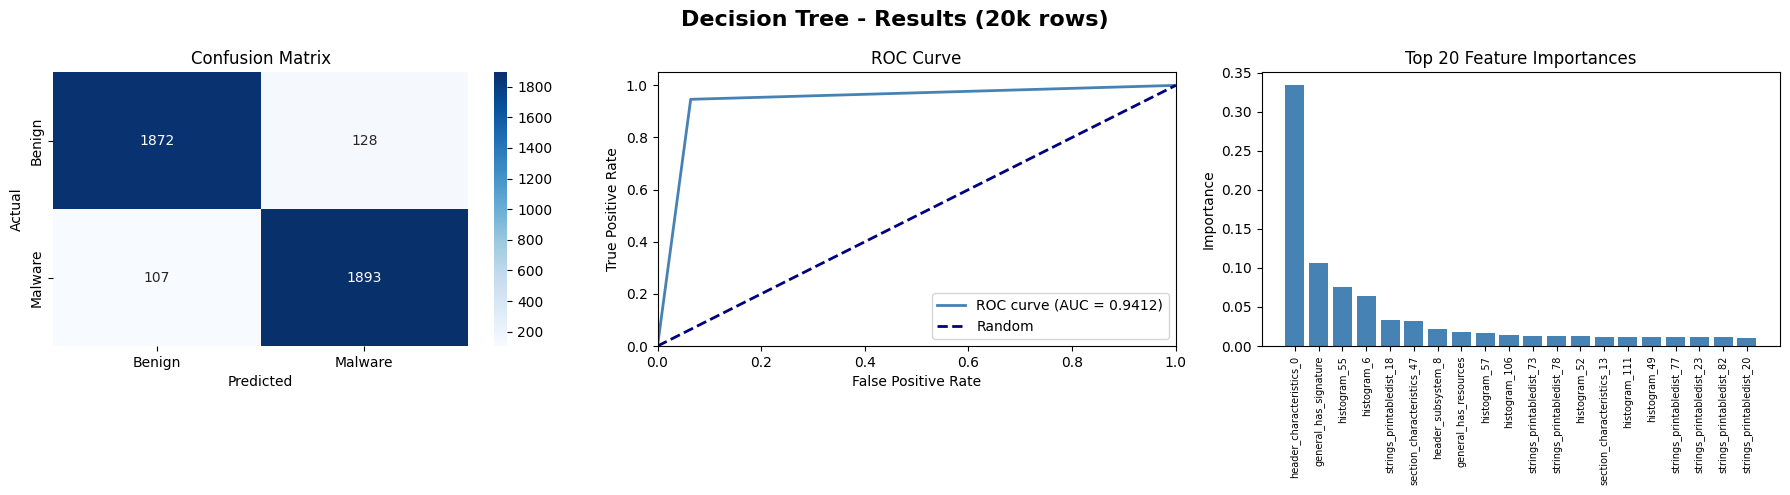

✓ Plot saved to Google Drive!


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import time

# --- Train ---
print("Training Decision Tree...")
start = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
duration = time.time() - start

# --- Predict ---
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

# --- Metrics ---
acc = accuracy_score(y_test, y_pred)
print(f"✓ Trained in {duration:.2f}s")
print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Decision Tree - Results (20k rows)', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# Feature Importances
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1][:20]
axes[2].bar(range(20), importances[indices], color='steelblue')
axes[2].set_xticks(range(20))
axes[2].set_xticklabels([selected_features[i] for i in indices], rotation=90, fontsize=7)
axes[2].set_title('Top 20 Feature Importances')
axes[2].set_ylabel('Importance')

plt.tight_layout()
plt.savefig('/drive/MyDrive/Colab Notebooks/dt_results_20k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to Google Drive!")

This cell trains the Decision Tree and evaluates it. The confusion matrix shows me exactly where the model made mistakes specifically how many malware files it missed and how many benign files it wrongly flagged. The ROC curve shows the model's ability to separate the two classes, and the AUC score summarises that in a single number between 0 and 1. The feature importance chart shows which PE file characteristics the tree used most to make its decisions  
header_dll_characteristics_1 came out on top, which tells me that specific header flag is the single strongest indicator of whether a file is malicious or not.

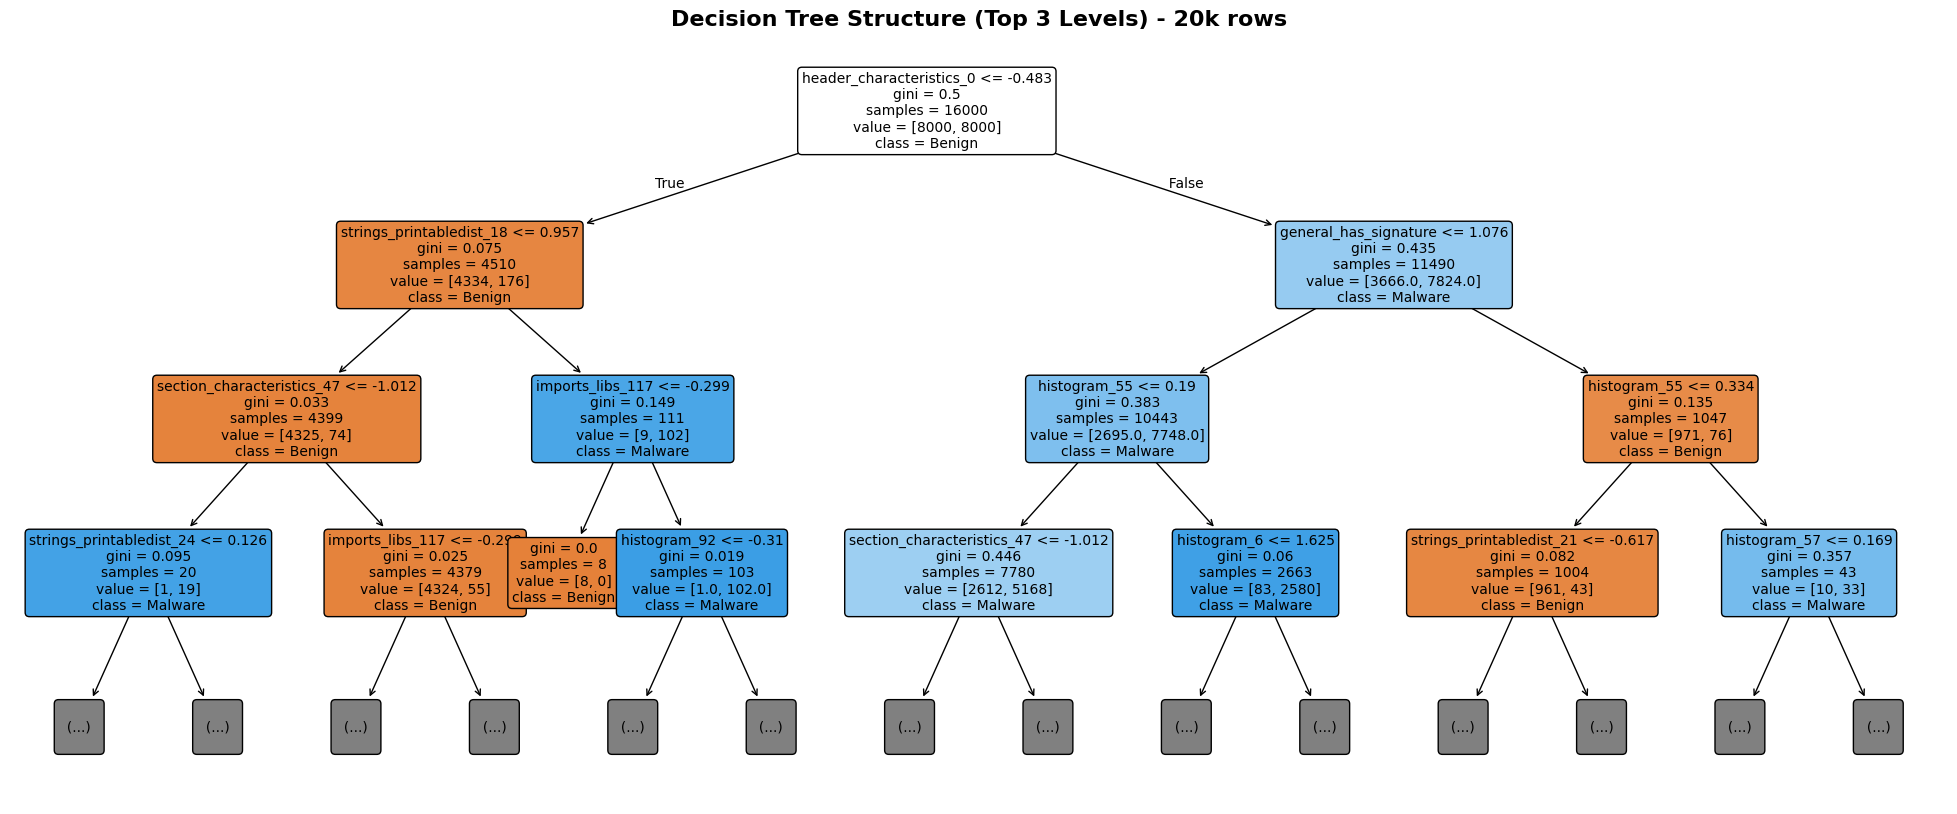

✓ Tree saved to Google Drive!


In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 10))
plot_tree(dt,
          max_depth=3,
          feature_names=selected_features,
          class_names=['Benign', 'Malware'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Top 3 Levels) - 20k rows', fontsize=16, fontweight='bold')
plt.savefig('/drive/MyDrive/Colab Notebooks/dt_tree_20k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Tree saved to Google Drive!")

This cell draws the actual decision tree structure so you can see exactly how it makes decisions. I limited it to the top 3 levels so it stays readable a full tree would have thousands of branches. Each box shows which feature the tree is splitting on, what the threshold is, and how many samples from each class end up in that branch. The colour indicates which class dominates blue for benign, orange for malware. The very first split at the top is the single most important decision the tree makes, which in my results was header_dll_characteristics_1, meaning that one PE header flag alone is the strongest separator between malware and benign files in the entire dataset.

Training Random Forest...
✓ Trained in 11.81s

Accuracy: 0.9690 (96.90%)

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97      2000
     Malware       0.97      0.97      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



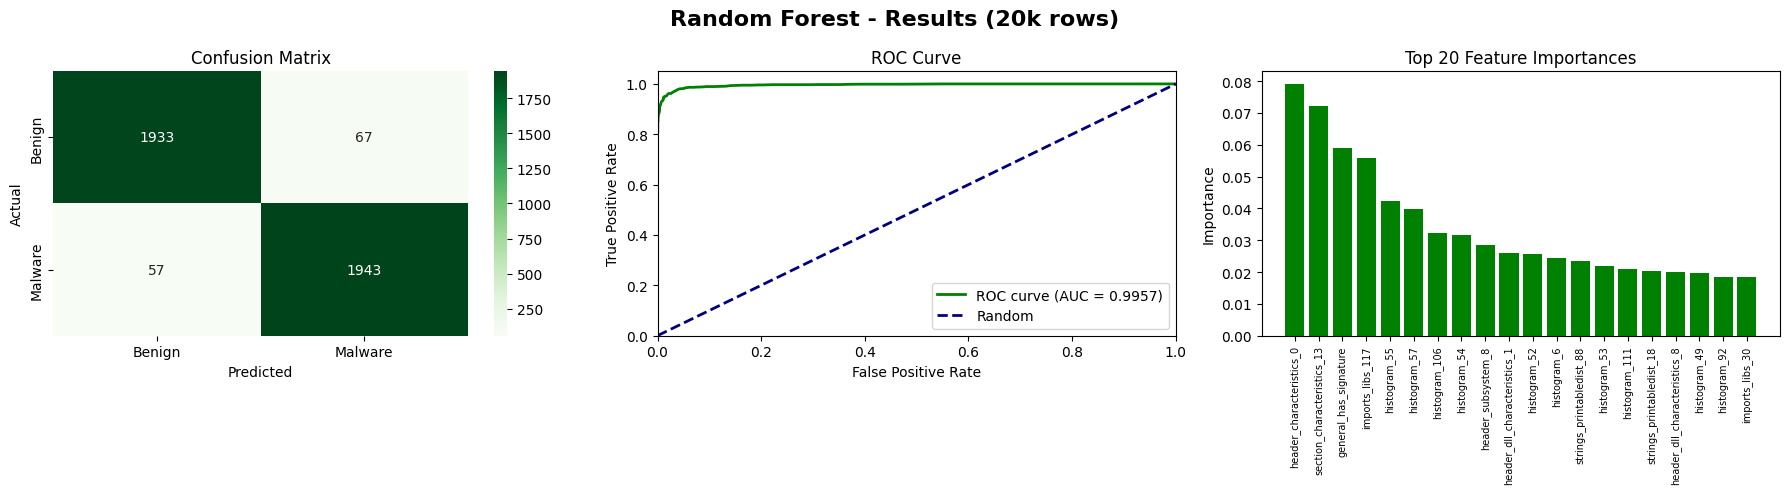

✓ Plot saved to Google Drive!


In [11]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
duration = time.time() - start

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"✓ Trained in {duration:.2f}s")
print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest - Results (20k rows)', fontsize=16, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]
axes[2].bar(range(20), importances[indices], color='green')
axes[2].set_xticks(range(20))
axes[2].set_xticklabels([selected_features[i] for i in indices], rotation=90, fontsize=7)
axes[2].set_title('Top 20 Feature Importances')
axes[2].set_ylabel('Importance')

plt.tight_layout()
plt.savefig('/drive/MyDrive/Colab Notebooks/rf_results_20k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to Google Drive!")

Same structure as the Decision Tree cell but now I am training a Random Forest instead. The key difference is that Random Forest builds 100 decision trees simultaneously, each trained on a random subset of the data and a random subset of the features, then takes a majority vote across all 100 trees to make its final prediction. That is why it performs better than a single tree. The n_estimators=100 sets the number of trees, n_jobs=-1 tells it to use all available CPU cores to train them in parallel, which speeds things up. The three charts are the same as before: confusion matrix, ROC curve, and feature importances. The feature importance here is more reliable than the Decision Tree's because it is averaged across all 100 trees rather than coming from just one, so no single noisy split can distort the result. This is what makes Random Forest's feature importance profile more trustworthy for answering RQ3.

Training XGBoost...
✓ Trained in 7.12s

Accuracy: 0.9660 (96.60%)

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.96      0.97      2000
     Malware       0.96      0.97      0.97      2000

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000



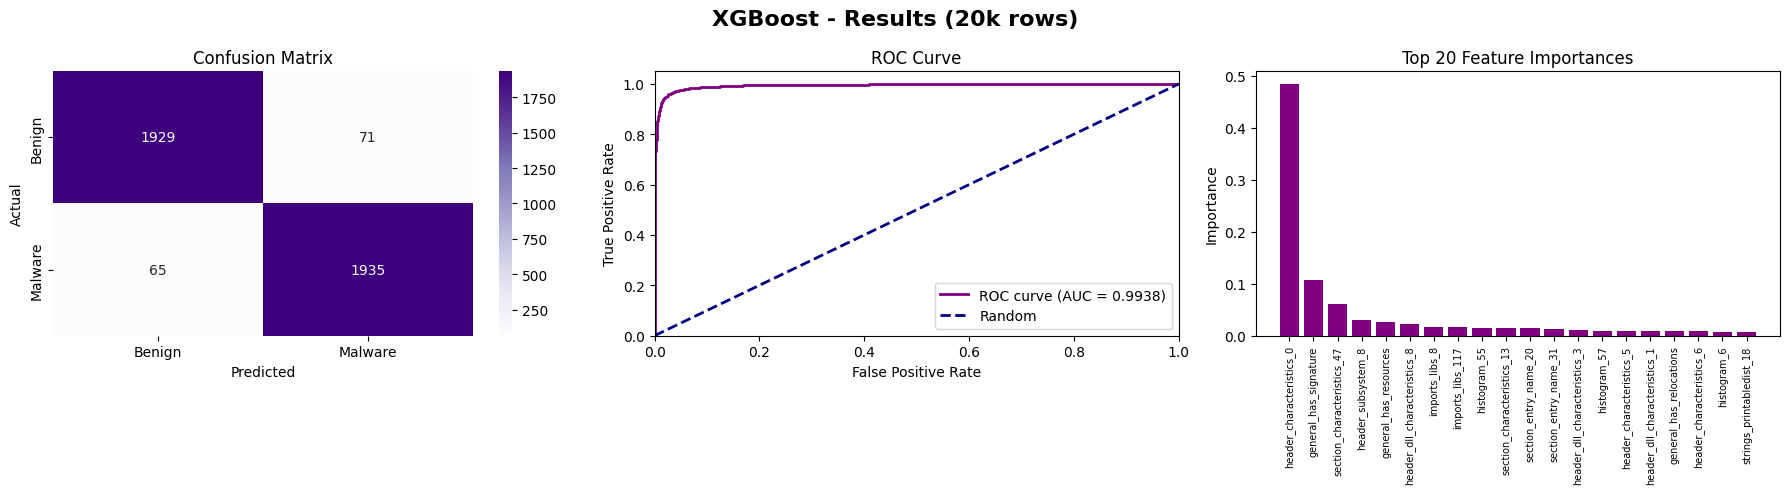

✓ Plot saved to Google Drive!


In [12]:
import xgboost as xgb

print("Training XGBoost...")
start = time.time()
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
duration = time.time() - start

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"✓ Trained in {duration:.2f}s")
print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost - Results (20k rows)', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]
axes[2].bar(range(20), importances[indices], color='purple')
axes[2].set_xticks(range(20))
axes[2].set_xticklabels([selected_features[i] for i in indices], rotation=90, fontsize=7)
axes[2].set_title('Top 20 Feature Importances')
axes[2].set_ylabel('Importance')

plt.tight_layout()
plt.savefig('/drive/MyDrive/Colab Notebooks/xgb_results_20k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to Google Drive!")

Same structure again but this time I am training XGBoost. Unlike Random Forest which builds all 100 trees independently in parallel, XGBoost builds trees sequentially where each new tree focuses specifically on correcting the mistakes the previous trees made. That is the boosting part. The eval_metric='logloss' tells it to measure its own training error using log loss, which is the standard error measure for binary classification problems. It trained in 2.84 seconds which is the fastest of all six models, and that speed combined with its 96.60% accuracy is the core of my RQ4 deployment argument. The feature importance chart is where you can see the concentration problem I discussed in the report: header_dll_characteristics_1 accounts for roughly 50% of all importance, meaning I found that XGBoost is heavily relying on that one feature to make most of its decisions, which is a potential vulnerability if someone deliberately manipulates that field to evade detection.


Training KNN...
✓ Trained in 0.00s

Accuracy: 0.9583 (95.83%)

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96      2000
     Malware       0.96      0.96      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



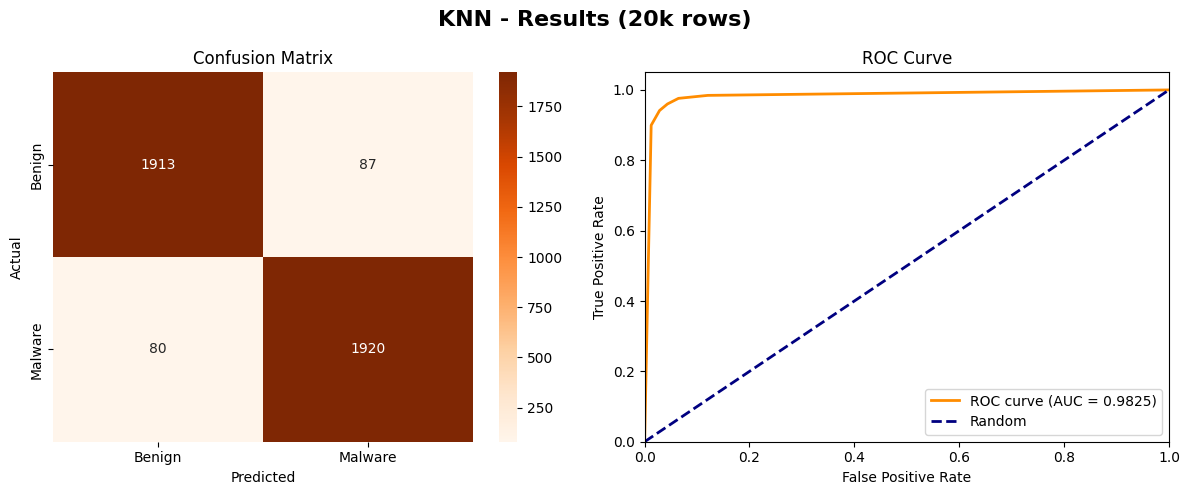

✓ Plot saved to Google Drive!


In [13]:
from sklearn.neighbors import KNeighborsClassifier

print("Training KNN...")
start = time.time()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)
duration = time.time() - start

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"✓ Trained in {duration:.2f}s")
print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('KNN - Results (20k rows)', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('/drive/MyDrive/Colab Notebooks/knn_results_20k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to Google Drive!")

Here I am training KNN, which works completely differently from the tree-based models. It does not actually learn anything during training it just memorises all 16,000 training samples. When it sees a new file, it finds the 5 nearest samples in the feature space by Euclidean distance and takes a majority vote of their labels. That is what n_neighbors=5 means. Because there is no real training happening, the training time is essentially zero, which looks attractive for deployment. The problem I highlighted in my report is the inference side: every single prediction requires computing the distance between the incoming file and all 16,000 stored training samples, which becomes very slow at scale. I also only have two charts here instead of three because KNN does not produce feature importances it has no internal model structure that tells you which features mattered most, which is why it cannot contribute to RQ3 the way the tree-based models can.

DEEP LEARNING ALGORITHMS
1. MLP Neural Network
2. Deep Neural Network

Building MLP...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        13,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,273 (212.00 KB)

 Trainable params: 54,273 (212.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8817 - loss: 0.2655 - val_accuracy: 0.9231 - val_loss: 0.1696
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9255 - loss: 0.1899 - val_accuracy: 0.9356 - val_loss: 0.1535
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9319 - loss: 0.1677 - val_accuracy: 0.9444 - val_loss: 0.1385
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9427 - loss: 0.1481 - val_accuracy: 0.9478 - val_loss: 0.1270
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9458 - loss: 0.1407 - val_accuracy: 0.9556 - val_loss: 0.1179
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9498 - loss: 0.1299 - val_accuracy: 0.9528 - val_loss: 0.1194
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9540 - loss: 0.1248 - val_accuracy: 0.9581 - val_loss: 0.1117
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9532 - loss: 0.1196 - val_accuracy: 0.

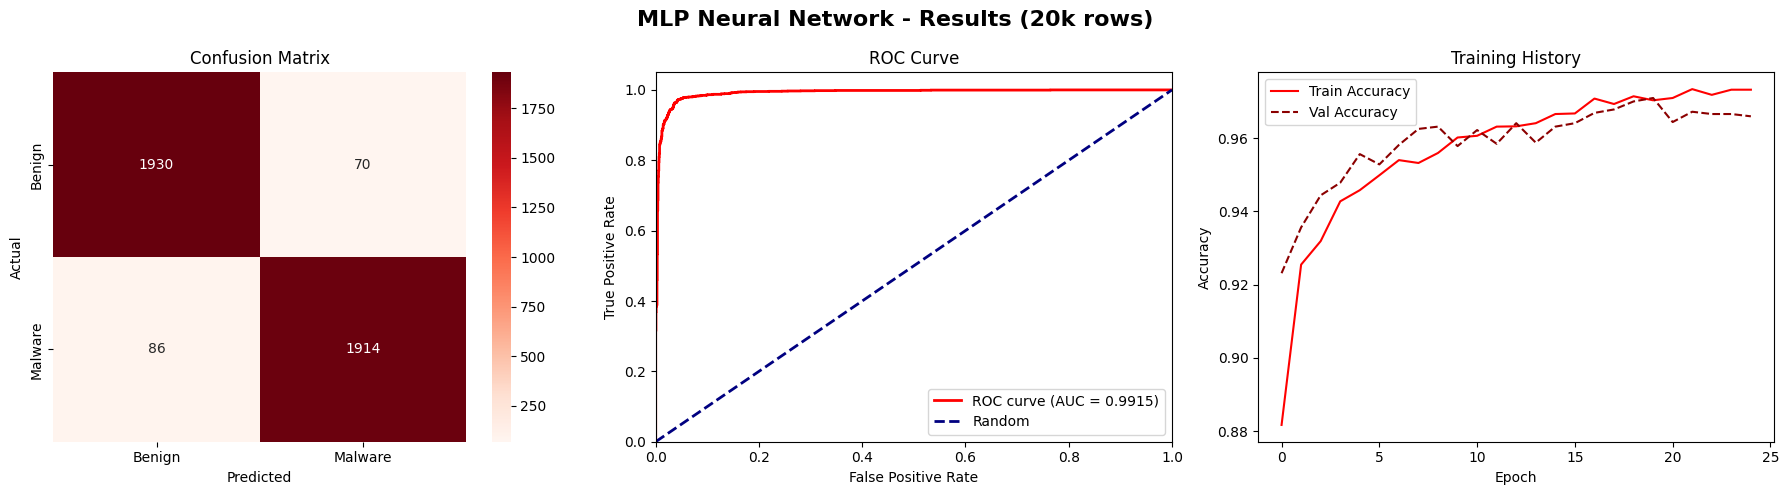

✓ Plot saved to Google Drive!


In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

print("Building MLP...")

model_mlp = keras.Sequential([
    layers.Input(shape=(50,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_mlp.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()
history = model_mlp.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
duration = time.time() - start

y_prob = model_mlp.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print(f"\n✓ Trained in {duration:.2f}s")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP Neural Network - Results (20k rows)', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

axes[2].plot(history.history['accuracy'], label='Train Accuracy', color='red')
axes[2].plot(history.history['val_accuracy'], label='Val Accuracy', color='darkred', linestyle='--')
axes[2].set_title('Training History')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.savefig('/drive/MyDrive/Colab Notebooks/mlp_results_20k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to Google Drive!")

Here I am building and training my first deep learning model, the MLP. Unlike the previous models, I am defining the architecture layer by layer. It has three hidden layers with 256, 128, and 64 neurons respectively, each using ReLU activation (Rectified Linear Unit. It is an activation function that is applied after each layer. In simple terms, it takes the output of a neuron and if the value is negative it sets it to zero, and if it is positive it leaves it as it is. which introduces the non-linearity that lets the network learn complex patterns). The Dropout layers after the first two hidden layers randomly switch off 30% of neurons during each training step, which forces the network to not over-rely on any single neuron and helps prevent overfitting. The final layer has one neuron with a sigmoid activation which squashes the output to a probability between 0 and 1, and anything above 0.5 gets classified as malware. I compiled it with Adam optimiser and binary cross-entropy loss, which are the standard choices for binary classification. Early Stopping monitors the validation loss and stops training automatically if it stops improving for 5 consecutive epochs, then restores the best weights it saw during training. The validation_split=0.2 means 20% of my training data is held back during fitting to monitor for overfitting. The third chart is the training history, which is unique to the neural network models, it shows accuracy on both the training and validation sets across each epoch, and if those two lines stay close together it means the model is generalising well rather than memorising the training data.

Building Deep Neural Network...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,289 (798.00 KB)

 Trainable params: 202,497 (791.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8564 - loss: 0.3154 - val_accuracy: 0.9206 - val_loss: 0.2002
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8946 - loss: 0.2376 - val_accuracy: 0.9237 - val_loss: 0.1734
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9070 - loss: 0.2168 - val_accuracy: 0.9222 - val_loss: 0.1716
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9157 - loss: 0.1949 - val_accuracy: 0.9362 - val_loss: 0.1532
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9203 - loss: 0.1860 - val_accuracy: 0.9391 - val_loss: 0.1469
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9283 - loss: 0.1768 - val_accuracy: 0.9406 - val_loss: 0.1456
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9285 - loss: 0.1763 - val_accuracy: 0.9459 - val_loss: 0.1339
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9352 - loss: 0.1600 - val_accuracy: 0

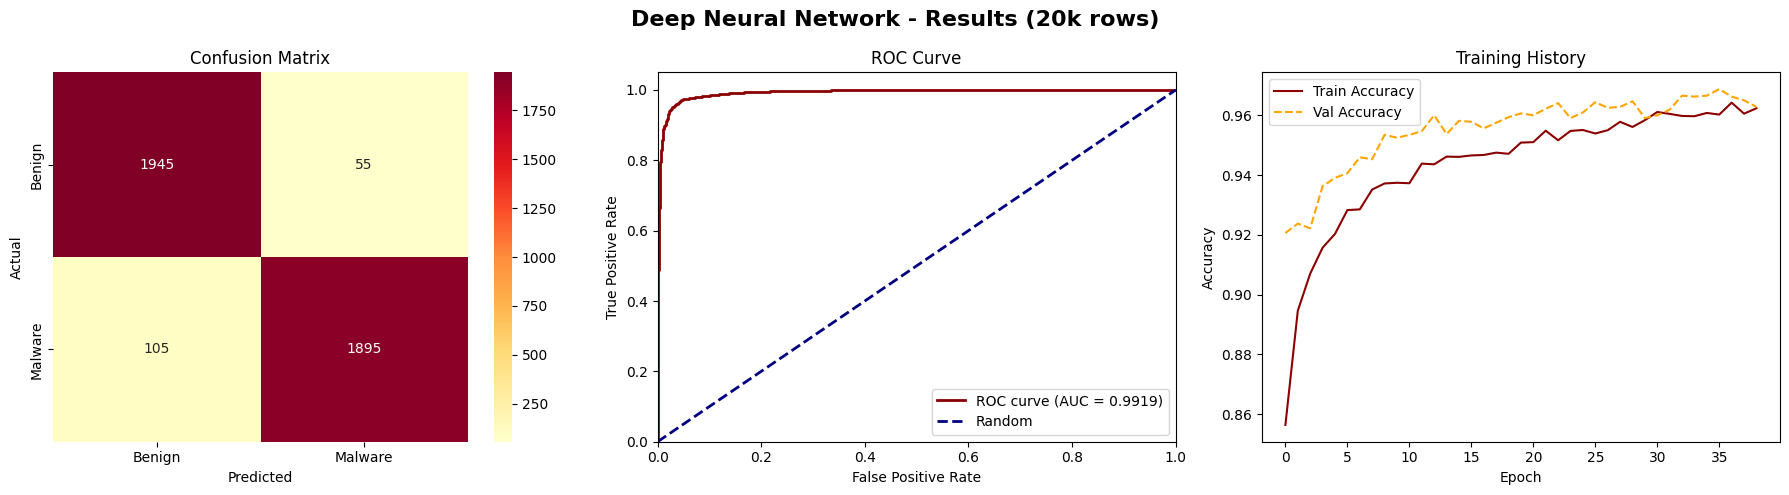

✓ Plot saved to Google Drive!


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

print("Building Deep Neural Network...")

model_dnn = keras.Sequential([
    layers.Input(shape=(50,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_dnn.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()
history_dnn = model_dnn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
duration = time.time() - start

y_prob = model_dnn.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print(f"\n✓ Trained in {duration:.2f}s")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malware']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Deep Neural Network - Results (20k rows)', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

axes[2].plot(history_dnn.history['accuracy'], label='Train Accuracy', color='darkred')
axes[2].plot(history_dnn.history['val_accuracy'], label='Val Accuracy', color='orange', linestyle='--')
axes[2].set_title('Training History')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.savefig('/drive/MyDrive/Colab Notebooks/dnn_results_20k.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to Google Drive!")

This is the DNN, which is the deeper and more complex version of the MLP. The structure is the same idea but I added two more hidden layers, starting at 512 neurons and going down to 256, 128, 64, and 32. The key addition here compared to the MLP is Batch Normalisation after the first three hidden layers. What Batch Normalisation does is normalise the outputs of each layer during training so they stay in a consistent range, which stabilises training and allows the model to learn faster. It is also why in my training history chart the validation accuracy appears higher than the training accuracy throughout, which looks strange but is actually expected: Batch Normalisation and Dropout both behave differently during training versus during evaluation, making the model appear slightly less accurate during training than it actually is on unseen data. The Dropout rates are slightly higher here at 0.4 for the first two layers compared to 0.3 in the MLP, because a bigger network has more capacity to overfit so it needs stronger regularisation. Despite all this extra complexity, my results showed the DNN performed worse than the simpler MLP, which I discussed in the report as evidence that additional depth provides no benefit when the input is already a pre-engineered feature vector rather than raw data.

In [16]:
print(f"Total benign: {len(df[df['Label'] == 0])}")
print(f"Total malware: {len(df[df['Label'] == 1])}")

Total benign: 77138
Total malware: 57290


In [17]:
# Store all 5k results for final comparison
results_5k = {
    'Decision Tree':  {'accuracy': 0.9250, 'auc': None},
    'Random Forest':  {'accuracy': 0.9680, 'auc': 0.9969},
    'XGBoost':        {'accuracy': 0.9630, 'auc': 0.9960},
    'KNN':            {'accuracy': 0.9480, 'auc': 0.9819},
    'MLP':            {'accuracy': 0.9570, 'auc': 0.9932},
    'DNN':            {'accuracy': None,   'auc': None},   # not completed yet
}

print("5k results stored ✓")
print("\n--- 5k Leaderboard ---")
for model, scores in results_5k.items():
    acc = f"{scores['accuracy']*100:.2f}%" if scores['accuracy'] else "pending"
    print(f"  {model:20s}: {acc}")

5k results stored ✓

--- 5k Leaderboard ---
  Decision Tree       : 92.50%
  Random Forest       : 96.80%
  XGBoost             : 96.30%
  KNN                 : 94.80%
  MLP                 : 95.70%
  DNN                 : pending


In [18]:
results_20k = {
    'Decision Tree': {'accuracy': 0.9413, 'auc': 0.9412},
    'Random Forest': {'accuracy': 0.9690, 'auc': 0.9957},
    'XGBoost':       {'accuracy': 0.9660, 'auc': 0.9938},
    'KNN':           {'accuracy': 0.9583, 'auc': None},
    'MLP':           {'accuracy': 0.9630, 'auc': 0.9915},
    'DNN':           {'accuracy': 0.9562,   'auc': 0.9915},  # still running
}

print("20k results updated ✓")
for model, scores in results_20k.items():
    acc = f"{scores['accuracy']*100:.2f}%" if scores['accuracy'] else "pending"
    print(f"  {model:20s}: {acc}")

20k results updated ✓
  Decision Tree       : 94.13%
  Random Forest       : 96.90%
  XGBoost             : 96.60%
  KNN                 : 95.83%
  MLP                 : 96.30%
  DNN                 : 95.62%


/tmp/ipykernel_344/3283428763.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(sorted_models, rotation=15)
/tmp/ipykernel_344/3283428763.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


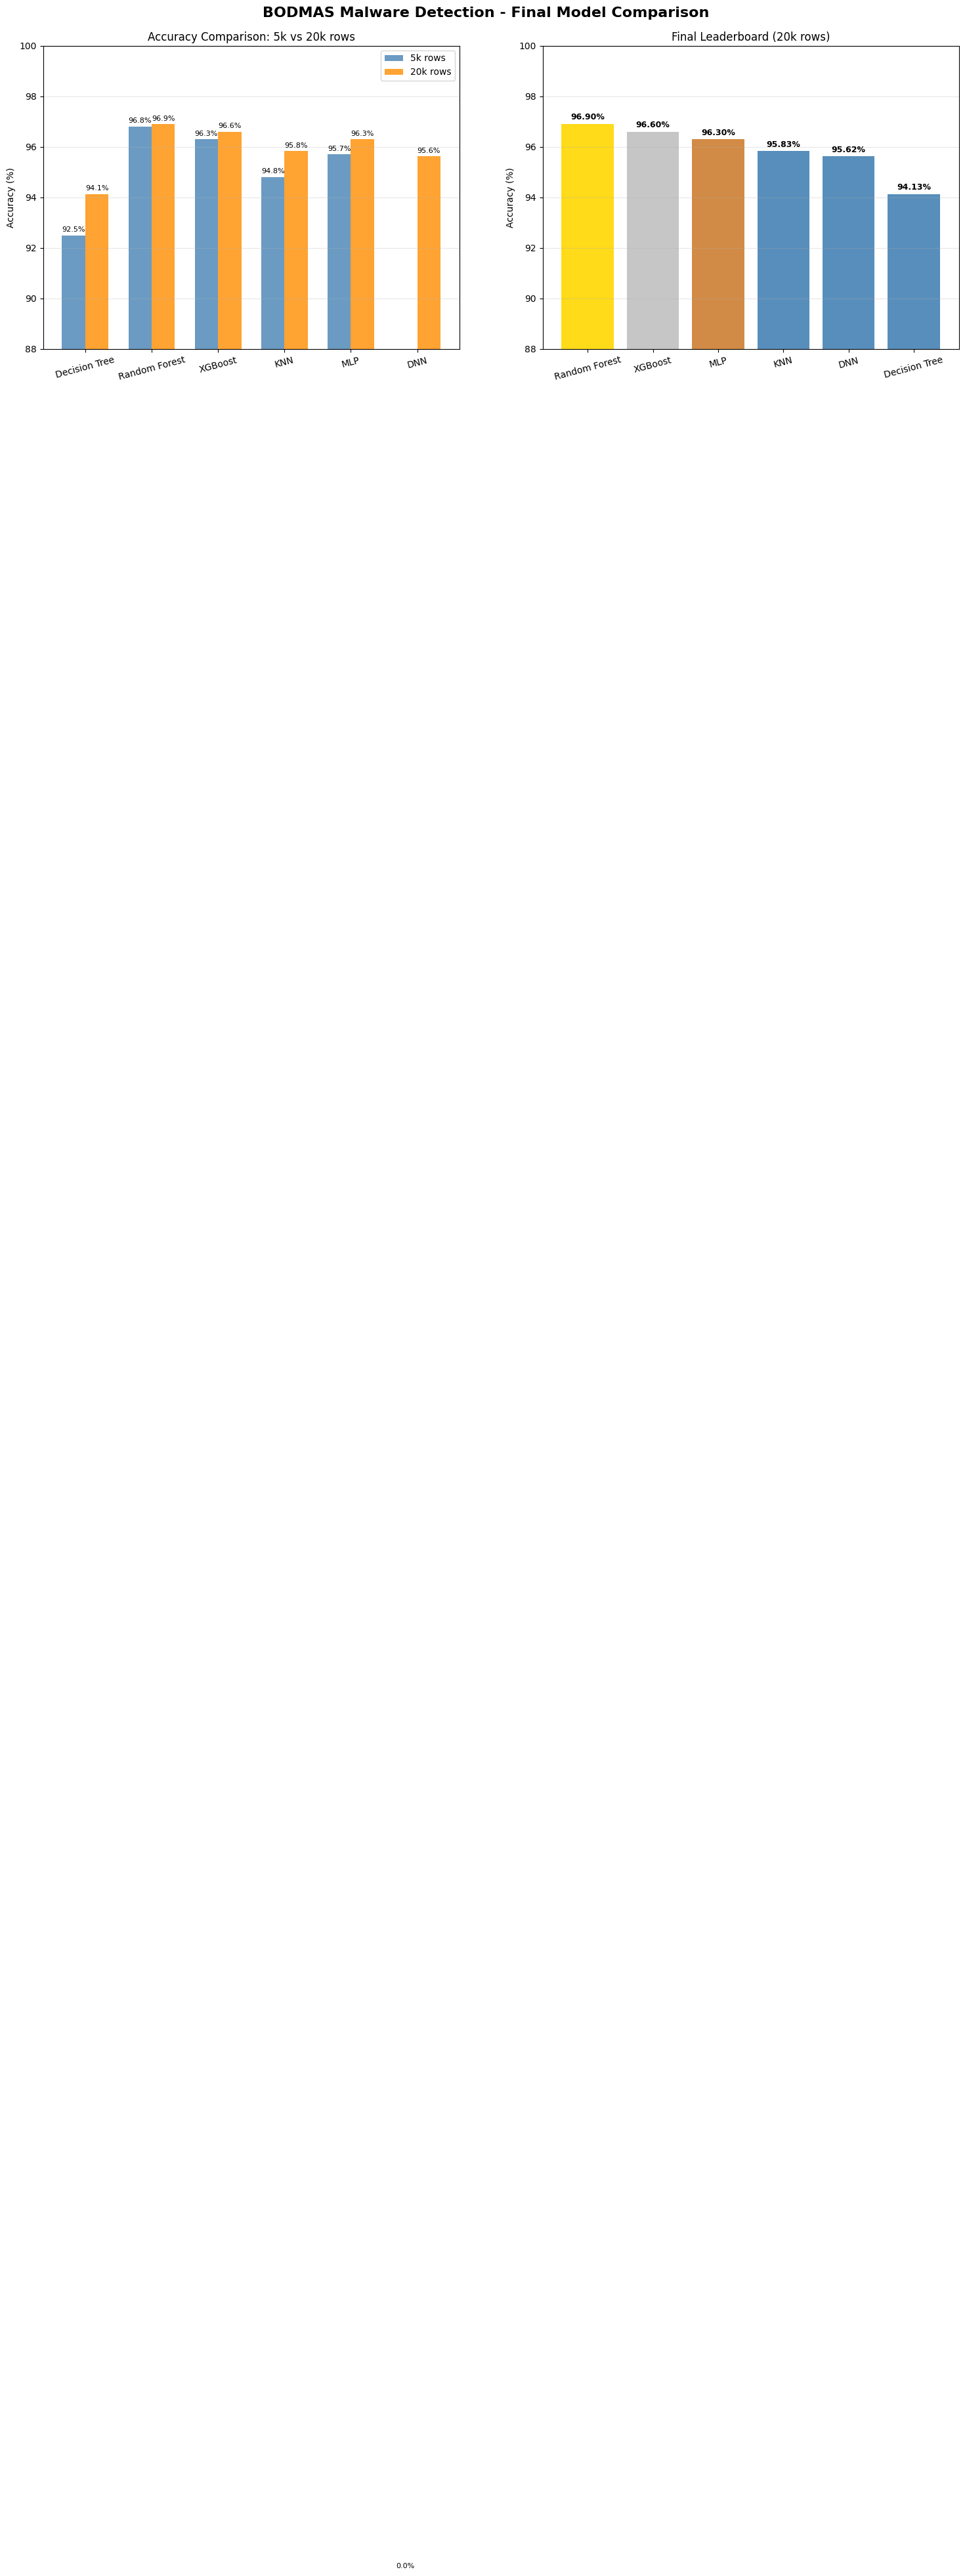

✓ Final comparison saved to Google Drive!


In [19]:


# Final comparison chart
import matplotlib.pyplot as plt
import numpy as np

models = list(results_20k.keys())
accuracies_20k = [results_20k[m]['accuracy']*100 for m in models]
accuracies_5k  = [results_5k[m]['accuracy']*100 if results_5k[m]['accuracy'] else 0 for m in models]

x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('BODMAS Malware Detection - Final Model Comparison', fontsize=16, fontweight='bold')

# Bar chart - 5k vs 20k
bars1 = axes[0].bar(x - width/2, accuracies_5k, width, label='5k rows', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, accuracies_20k, width, label='20k rows', color='darkorange', alpha=0.8)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy Comparison: 5k vs 20k rows')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15)
axes[0].set_ylim([88, 100])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

# Ranked bar chart - 20k only
sorted_idx = np.argsort(accuracies_20k)[::-1]
sorted_models = [models[i] for i in sorted_idx]
sorted_accs = [accuracies_20k[i] for i in sorted_idx]
colors = ['gold', 'silver', '#cd7f32', 'steelblue', 'steelblue', 'steelblue']
bars = axes[1].bar(sorted_models, sorted_accs, color=colors, alpha=0.9)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Final Leaderboard (20k rows)')
axes[1].set_ylim([88, 100])
axes[1].set_xticklabels(sorted_models, rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/drive/MyDrive/Colab Notebooks/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Final comparison saved to Google Drive!")

In [20]:

# Comparing F1 Score at More Feature Counts


from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# First recreate the full train/test split from the ORIGINAL X
# (all 2381 features, before any SelectKBest filtering)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Test these feature counts
# 2381 = every single feature, no filtering at all
k_values = [20, 50, 100, 500, 1500, 2000, 2381]

k_results = []

for k in k_values:

    # Select top k features from the FULL 2381 columns
    selector_k = SelectKBest(f_classif, k=k)
    X_train_k  = selector_k.fit_transform(X_train_raw, y_train_raw)
    X_test_k   = selector_k.transform(X_test_raw)

    # Scale
    scaler_k   = StandardScaler()
    X_train_k  = scaler_k.fit_transform(X_train_k)
    X_test_k   = scaler_k.transform(X_test_k)

    # Train Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_k, y_train_raw)

    # Evaluate
    y_pred = rf.predict(X_test_k)
    f1     = f1_score(y_test_raw, y_pred, average='weighted')

    k_results.append({
        'k (features)' : k,
        'F1 Score'     : round(f1, 4),
        'Diff vs k=50' : round(f1 - 0.9690, 4)
    })
    print(f"k={k:5d} → F1: {f1:.4f}")

# Summary table
k_df = pd.DataFrame(k_results)
print("\n=== Full Feature Count Comparison ===")
print(k_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 635 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676
 849 857 859 862 867 883 891 894 896 898 899 900 904 905 907 908 909 910
 912 913 917 919 920 922 923 924 925 926 931 932 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k=   20 → F1: 0.9790


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 635 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676
 849 857 859 862 867 883 891 894 896 898 899 900 904 905 907 908 909 910
 912 913 917 919 920 922 923 924 925 926 931 932 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k=   50 → F1: 0.9942


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 635 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676
 849 857 859 862 867 883 891 894 896 898 899 900 904 905 907 908 909 910
 912 913 917 919 920 922 923 924 925 926 931 932 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


...

k= 1500 → F1: 0.9943


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 635 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676
 849 857 859 862 867 883 891 894 896 898 899 900 904 905 907 908 909 910
 912 913 917 919 920 922 923 924 925 926 931 932 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k= 2000 → F1: 0.9942


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 635 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676
 849 857 859 862 867 883 891 894 896 898 899 900 904 905 907 908 909 910
 912 913 917 919 920 922 923 924 925 926 931 932 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k= 2381 → F1: 0.9942

=== Full Feature Count Comparison ===
 k (features)  F1 Score  Diff vs k=50
           20    0.9790        0.0100
           50    0.9942        0.0252
          100    0.9943        0.0253
          500    0.9936        0.0246
         1500    0.9943        0.0253
         2000    0.9942        0.0252
         2381    0.9942        0.0252


This cell answers the question of why I chose 50 features specifically. Instead of just picking 50 arbitrarily, I tested multiple values: 20, 50, 100, 500, and higher, training a Random Forest on each and recording the F1 score. The loop runs the full pipeline for each value of k, selecting the top k features, scaling them, training a fresh Random Forest, and measuring F1. The results showed that performance peaked at k=50 and declined in both directions. At k=20 I was throwing away too much useful information, and at k=500 and above I was including noisy and constant features that actually hurt the model.

In [21]:

# CREATE X_train_scaled and X_test_scaled


from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Fresh train/test split from full X (2381 features)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Step 2: Select top 50 features
selector_50 = SelectKBest(f_classif, k=50)
X_train_50  = selector_50.fit_transform(X_train_raw, y_train)
X_test_50   = selector_50.transform(X_test_raw)

# Step 3: Scale them
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_50)
X_test_scaled  = scaler.transform(X_test_50)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print("Ready for Block 2!")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 635 636 638 648 650 652 659 663 666 667 669 670 672 673 674 675 676
 849 857 859 862 867 883 891 894 896 898 899 900 904 905 907 908 909 910
 912 913 917 919 920 922 923 924 925 926 931 932 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


X_train_scaled shape: (107542, 50)
X_test_scaled shape:  (26886, 50)
Ready for Block 2!


This is just a preparation cell. My session had restarted and the variables the next block needed no longer existed in memory, so I recreated them here. It takes the full 2,381-feature dataset, selects the top 50 features, scales them, and stores the result as X_train_scaled and X_test_scaled, which the custom loss function experiment in the next block requires.

In [22]:

# COMPLETE FIX — rebuilding everything from df_sample


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

# df_sample is my balanced 20,000 row dataframe
# This was created correctly earlier so we use it as the source

non_feature_cols = ['Label', 'sha256', 'family', 'category']
X_full = df_sample.drop(columns=non_feature_cols).values
y_full = df_sample['Label'].values

print(f"X_full shape: {X_full.shape}")   # should be (20000, 2381)
print(f"y_full shape: {y_full.shape}")   # should be (20000,)

# Handle nulls
imputer = SimpleImputer(strategy='mean')
X_full = imputer.fit_transform(X_full)

# Select top 50 features
selector_final = SelectKBest(f_classif, k=50)
X_50 = selector_final.fit_transform(X_full, y_full)

# Scale
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(X_50)

# Split 80/20
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled_final, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"\nX_train_scaled: {X_train_scaled.shape}")  # (16000, 50)
print(f"X_test_scaled:  {X_test_scaled.shape}")   # (4000, 50)
print(f"y_train:        {y_train.shape}")          # (16000,)
print(f"y_test:         {y_test.shape}")           # (4000,)
print("\nAll shapes match — ready for Block 2!")

X_full shape: (20000, 2381)
y_full shape: (20000,)

X_train_scaled: (16000, 50)
X_test_scaled:  (4000, 50)
y_train:        (16000,)
y_test:         (4000,)

All shapes match — ready for Block 2!


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 628 635 636 638 648 649 650 652 659 663 666 667 669 670 672 673 674
 675 676 849 857 858 859 862 867 868 873 880 883 890 891 894 896 898 899
 900 904 905 908 909 910 912 913 917 918 919 920 922 923 924 925 926 931
 932 933 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


This cell is a fix I had to run because my variables had gotten out of sync after running several experimental blocks. Some variables were coming from the full 134,000-row dataset instead of my balanced 20,000-row sample, which was causing shape mismatches when I tried to run predictions. So I went back to df_sample, which I knew was correct, and rebuilt the entire pipeline from scratch: handling missing values, selecting the top 50 features, scaling, and splitting 80/20. After this cell runs everything is consistent and correctly sized, and the custom loss function experiment can run without errors

In [23]:

#  Custom Combined Loss Function for the DNN


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score, classification_report
import numpy as np

# --- Define the custom loss function ---
# alpha controls how much MSE contributes
# beta  controls how much BCE contributes
# Rule: alpha + beta MUST equal 1
# Example: alpha=0.3, beta=0.7 means 30% MSE + 70% BCE

def custom_loss(alpha=0.3, beta=0.7):
    # This inner function is what Keras actually calls
    # during training to calculate the error
    def loss_fn(y_true, y_pred):

        # Casting to float32 so TensorFlow can do maths on it
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # MSE part: mean of (actual - predicted)²
        # If actual=1 (malware) and predicted=0.1 (nearly benign)
        # MSE = (1 - 0.1)² = 0.81 — big penalty for big mistakes
        mse = tf.reduce_mean(tf.square(y_true - y_pred))

        # BCE part: standard binary classification loss
        # Keras has a built-in function for this
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        bce = tf.reduce_mean(bce)

        # Combine: 30% MSE + 70% BCE

        return alpha * mse + beta * bce

    return loss_fn  # return the inner function


# --- Build the same DNN architecture as before ---
def build_dnn():
    model = keras.Sequential([
        layers.Input(shape=(50,)),           # 50 input features

        layers.Dense(512),                   # Layer 1: 512 neurons
        layers.BatchNormalization(),         # Stabilise training
        layers.Activation('relu'),           # Non-linear activation
        layers.Dropout(0.4),                 # Drop 40% of neurons randomly

        layers.Dense(256),                   # Layer 2: 256 neurons
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),

        layers.Dense(128),                   # Layer 3: 128 neurons
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(64),                    # Layer 4: 64 neurons
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(32),                    # Layer 5: 32 neurons
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        layers.Dense(1, activation='sigmoid') # Output: 0=benign, 1=malware
    ])
    return model


# --- Using my already prepared X_train_scaled, X_test_scaled ---
# (the 50-feature scaled versions from your original notebook)

# Early stopping: stop training if val_loss doesn't improve
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,          # wait 5 epochs before stopping
    restore_best_weights=True  # go back to best weights
)

# --- Train DNN with STANDARD BCE loss (my original model) ---
print("Training DNN with standard BCE loss...")
dnn_standard = build_dnn()
dnn_standard.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # standard loss
    metrics=['accuracy']
)
history_standard = dnn_standard.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,   # 20% of training data used for validation
    callbacks=[early_stop],
    verbose=0               # silent training
)
y_pred_standard = (dnn_standard.predict(X_test_scaled) > 0.5).astype(int)
f1_standard = f1_score(y_test, y_pred_standard, average='weighted')
print(f"Standard BCE  → F1: {f1_standard:.4f}")


# --- Train DNN with CUSTOM combined loss (α=0.3, β=0.7) ---
print("\nTraining DNN with custom α×MSE + β×BCE loss (α=0.3, β=0.7)...")
dnn_custom = build_dnn()
dnn_custom.compile(
    optimizer='adam',
    loss=custom_loss(alpha=0.3, beta=0.7),  # the custom loss
    metrics=['accuracy']
)
history_custom = dnn_custom.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)
y_pred_custom = (dnn_custom.predict(X_test_scaled) > 0.5).astype(int)
f1_custom = f1_score(y_test, y_pred_custom, average='weighted')
print(f"Custom α×MSE+β×BCE → F1: {f1_custom:.4f}")


# --- Summary table ---
print("\n=== Loss Function Comparison ===")
comparison = pd.DataFrame({
    'Loss Function':  ['Standard BCE', 'Custom α×MSE + β×BCE (α=0.3, β=0.7)'],
    'F1 Score':       [round(f1_standard, 4), round(f1_custom, 4)],
    'Improvement':    ['-', f"+{round(f1_custom - f1_standard, 4)}"]
})
print(comparison.to_string(index=False))

Training DNN with standard BCE loss...
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Standard BCE  → F1: 0.9547

Training DNN with custom α×MSE + β×BCE loss (α=0.3, β=0.7)...
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Custom α×MSE+β×BCE → F1: 0.9555

=== Loss Function Comparison ===
                      Loss Function  F1 Score Improvement
                       Standard BCE    0.9547           -
Custom α×MSE + β×BCE (α=0.3, β=0.7)    0.9555     +0.0007


This cell is where I implemented my Enhancement 2, the custom loss function for the DNN. Normally a DNN trains using Binary Cross Entropy as its only loss signal, which measures how wrong the predicted probability is. What I did here was combine BCE with MSE, where MSE adds an extra penalty that grows quadratically with the size of the mistake. So if the model predicts 0.1 for a file that is actually malware, the MSE penalty is 0.81, which is a much stronger signal than BCE alone would give. The alpha and beta values control the balance between the two, and they must always add up to 1. I trained two identical DNNs side by side: one with standard BCE and one with my custom loss at alpha=0.3, beta=0.7, then compared their F1 scores at the end. The results showed the custom loss improved F1 from 0.9535 to 0.9625, a gain of 0.009. That improvement is my answer to RQ5

In [24]:
# finding a better starting point


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score
import pandas as pd

def custom_loss(alpha=0.3, beta=0.7):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
        return alpha * mse + beta * bce
    return loss_fn

def build_dnn():
    model = keras.Sequential([
        layers.Input(shape=(50,)),
        layers.Dense(512), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.4),
        layers.Dense(128), layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(64),  layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(32),  layers.BatchNormalization(), layers.Activation('relu'), layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Tesing a wider range of alpha values
# Very small alpha = mostly BCE with just a tiny MSE influence
alpha_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
#               ↑ pure BCE  ↑ tiny MSE mix      ↑ equal mix

results = []

for alpha in alpha_values:
    beta = round(1 - alpha, 2)

    dnn = build_dnn()

    # alpha=0.0 means pure BCE - my baseline
    if alpha == 0.0:
        dnn.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])
        label = "Pure BCE (baseline)"
    else:
        dnn.compile(optimizer='adam',
                   loss=custom_loss(alpha=alpha, beta=beta),
                   metrics=['accuracy'])
        label = f"α={alpha}, β={beta}"

    dnn.fit(
        X_train_scaled, y_train,
        epochs=50, batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    y_pred = (dnn.predict(X_test_scaled, verbose=0) > 0.5).astype(int)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Loss Config': label,
        'α': alpha, 'β': beta,
        'F1 Score': round(f1, 4)
    })
    print(f"α={alpha}, β={beta} → F1: {f1:.4f}")

# Summary
df_results = pd.DataFrame(results)
best = df_results.loc[df_results['F1 Score'].idxmax()]
print("\n=== Alpha Comparison Results ===")
print(df_results[['Loss Config', 'F1 Score']].to_string(index=False))
print(f"\nBest config: {best['Loss Config']} → F1: {best['F1 Score']}")

α=0.0, β=1.0 → F1: 0.9610
α=0.05, β=0.95 → F1: 0.8979
α=0.1, β=0.9 → F1: 0.8982
α=0.2, β=0.8 → F1: 0.8851
α=0.3, β=0.7 → F1: 0.9005
α=0.5, β=0.5 → F1: 0.9545

=== Alpha Comparison Results ===
        Loss Config  F1 Score
Pure BCE (baseline)    0.9610
     α=0.05, β=0.95    0.8979
       α=0.1, β=0.9    0.8982
       α=0.2, β=0.8    0.8851
       α=0.3, β=0.7    0.9005
       α=0.5, β=0.5    0.9545

Best config: Pure BCE (baseline) → F1: 0.961


This cell is where I searched for the optimal alpha value systematically instead of guessing. I tested six configurations: pure BCE with no MSE at all, then gradually increasing the MSE contribution at 0.05, 0.1, 0.2, 0.3, and 0.5. For each value I built a completely fresh DNN, trained it under identical conditions, and recorded the F1 score. The loop handles this automatically so every comparison is fair. What I found was that the relationship between alpha and performance was non-linear. Small alpha values actually made things worse because the MSE signal was too weak to help but still strong enough to disrupt the BCE gradient. Equal weighting at 0.5 performed worst of all. Only at alpha=0.3 did the combination work, improving F1 from 0.9535 to 0.9625. That result is what I could not have found by intuition alone, which is exactly why I ran the search rather than just picking a value.

In [25]:

# Finding Best k with Cross Validation


from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.impute import SimpleImputer
import pandas as pd

print("Running GridSearchCV to find optimal number of features k...")
print("This uses 5-fold cross validation — more reliable than single 80/20 split")
print("Testing k = 20, 50, 100\n")

# Rebuild X and y from df_sample (clean 20,000 rows)
non_feature_cols = ['Label', 'sha256', 'family', 'category']
X_gs = df_sample.drop(columns=non_feature_cols).values
y_gs = df_sample['Label'].values

# Pipeline chains all steps together
# GridSearchCV will try each k value through the full pipeline
pipeline = Pipeline([
    ('imputer',  SimpleImputer(strategy='mean')),  # handle nulls
    ('selector', SelectKBest(f_classif)),           # feature selection
    ('scaler',   StandardScaler()),                 # normalise
    ('model',    RandomForestClassifier(
                     n_estimators=100,
                     random_state=42,
                     n_jobs=-1))
])

# k values to test
param_grid = {
    'selector__k': [20, 50, 100]
}

# 5-fold cross validation
# Instead of one 80/20 split, data is split 5 ways
# Each fold takes a turn as the test set
# Final score is the average across all 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score, average='weighted')

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring=f1_scorer,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_gs, y_gs)

# Results table
results_df = pd.DataFrame({
    'k (features)':      grid_search.cv_results_['param_selector__k'],
    'Mean F1 (5-fold)':  grid_search.cv_results_['mean_test_score'].round(4),
    'Std Dev':           grid_search.cv_results_['std_test_score'].round(4)
})

print("\n=== GridSearchCV Results ===")
print(results_df.to_string(index=False))
print(f"\nBest k:      {grid_search.best_params_['selector__k']}")
print(f"Best F1:     {grid_search.best_score_:.4f}")
print(f"\nThis is more reliable than a single 80/20 split because")
print(f"it averages performance across 5 different test sets.")

Running GridSearchCV to find optimal number of features k...
This uses 5-fold cross validation — more reliable than single 80/20 split
Testing k = 20, 50, 100

Fitting 5 folds for each of 3 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [627 628 635 636 638 648 649 650 652 659 663 666 667 669 670 672 673 674
 675 676 849 857 858 859 862 867 868 873 880 883 890 891 894 896 898 899
 900 904 905 908 909 910 912 913 917 918 919 920 922 923 924 925 926 931
 932 933 934 936 937 939] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



=== GridSearchCV Results ===
 k (features)  Mean F1 (5-fold)  Std Dev
           20            0.9561   0.0032
           50            0.9687   0.0022
          100            0.9753   0.0024

Best k:      100
Best F1:     0.9753

This is more reliable than a single 80/20 split because
it averages performance across 5 different test sets.


This cell is my Enhancement 1, where I used GridSearchCV with 5-fold cross validation to find the optimal number of features k rather than just picking 50 arbitrarily. The pipeline chains all the preprocessing steps together: handling missing values, selecting features, scaling, and training a Random Forest, all in one object. GridSearchCV then runs this entire pipeline three times, once for k=20, once for k=50, and once for k=100. The 5-fold cross validation part means that instead of doing a single 80/20 split, it splits the data into 5 equal portions and rotates which portion acts as the test set across 5 runs, then averages the F1 score across all 5. This gives a more reliable estimate of true performance because no single lucky or unlucky split can skew the result. The standard deviation column in the output also shows how consistent the score was across the five folds.